In [1]:
import numpy as np
np.seterr(all="ignore")
import matplotlib.pyplot as plt
from SFstarred.cut2d import *

/home/felipe/miniconda3/envs/SFstarred/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
star_cutouts = read_hdf5_to_dict("data_products/F160W/cut_out_F160W.hdf5")

In [134]:
stars = star_cutouts["data_cutout_norm"]#['data_cutout']
noisemaps = star_cutouts['sigma2']#['sigma2']
stars.shape, noisemaps.shape

((4, 41, 41), (4, 41, 41))

In [136]:
np.median(stars[0]),np.median(noisemaps[0])

(np.float64(0.07584666534217338), np.float64(7.253644663205744e-05))

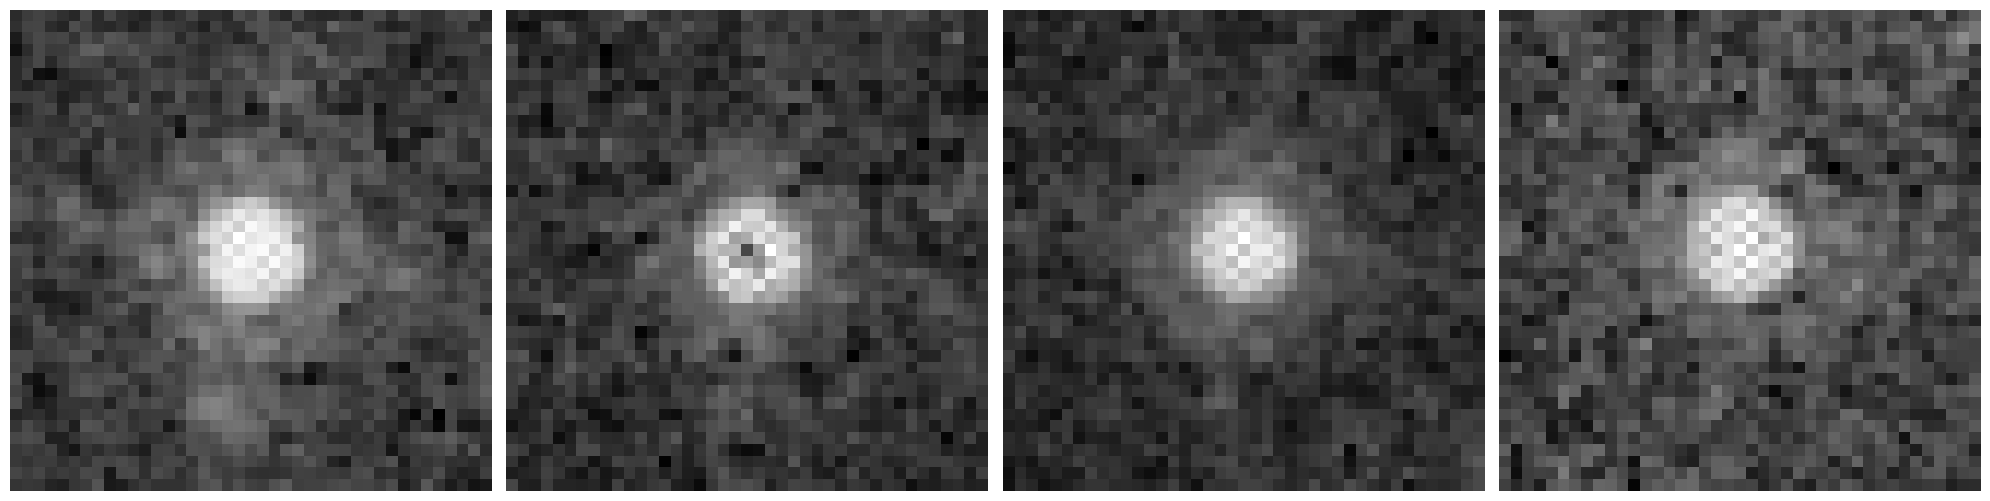

In [137]:
fig, axs = plt.subplots(1,4, figsize=(20,20))
for ax, star, noisemap in zip(axs, stars, noisemaps):
    ax.imshow(star/noisemap, cmap='gray'); ax.axis('off')
plt.tight_layout()

In [138]:
from starred.procedures import build_psf

result = build_psf(stars, noisemaps, subsampling_factor=2)
# result is a dictionary with the different components that can be useful,
# see the available entries:
result.keys()

/home/felipe/miniconda3/envs/SFstarred/lib/python3.12/site-packages/starred/utils/noise_utils.py:53: RuntimeWarning: Mean of empty slice
  noise_map = np.nanmean(centered_masked_noise_maps, axis=0)
optax.adabelief: 100%|██████████| 2000/2000 [00:17<00:00, 113.92it/s]


dict_keys(['model_instance', 'kwargs_psf', 'narrow_psf', 'full_psf', 'numerical_psf', 'moffat', 'models', 'residuals', 'analytical_optimizer_extra_fields', 'adabelief_extra_fields', 'chi2', 'chi2_per_stamp'])

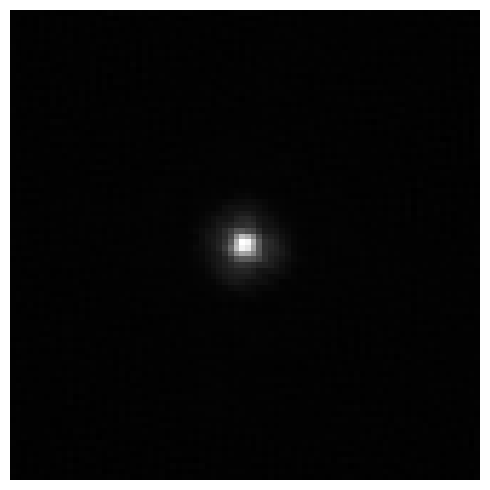

In [139]:
full_psf = result['full_psf']
plt.figure(figsize=(5,5))
plt.imshow(full_psf, cmap='gray')
plt.axis('off')
plt.tight_layout(); plt.show()

In [205]:
narrow_psfs = []
#for star, noisemap in zip(stars, noisemaps):
narrow = build_psf(stars, noisemaps, subsampling_factor=2)['narrow_psf']
narrow_psfs.append(narrow)
np.save('data_products/F160W/narrow_psfs.npy', narrow_psfs)

/home/felipe/miniconda3/envs/SFstarred/lib/python3.12/site-packages/starred/utils/noise_utils.py:53: RuntimeWarning: Mean of empty slice
  noise_map = np.nanmean(centered_masked_noise_maps, axis=0)
optax.adabelief: 100%|██████████| 2000/2000 [00:18<00:00, 107.31it/s]


In [206]:
narrow_psfs = np.load('data_products/F160W/narrow_psfs.npy')

In [207]:
narrow_psfs

array([[[-1.12908565e-05, -4.12901454e-06,  7.56008158e-05, ...,
          1.27837877e-04,  5.12096358e-06, -1.28592161e-04],
        [-9.53859781e-05, -1.42112076e-05, -7.20670550e-06, ...,
          2.32515176e-05,  8.98676299e-05, -2.13523999e-05],
        [-1.51637605e-05, -5.77750179e-05, -8.15981912e-06, ...,
         -6.46410335e-05,  9.36192009e-06, -2.30922233e-04],
        ...,
        [ 7.58083434e-06, -6.88762520e-05, -1.95790944e-05, ...,
         -4.25416056e-06,  1.35975104e-04,  9.23329208e-05],
        [ 3.48002330e-04, -2.26966440e-04, -2.61486384e-05, ...,
         -1.92950156e-05, -3.00079264e-04,  1.03534667e-05],
        [ 1.68635631e-06, -1.64703160e-04, -2.00648556e-05, ...,
          3.81464670e-05, -2.41437101e-06,  2.00126931e-04]]],
      shape=(1, 82, 82), dtype=float32)

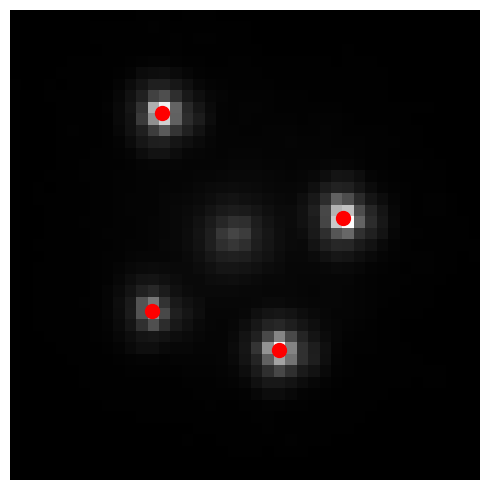

In [208]:
plt.figure(figsize=(5,5))
plt.imshow(star_cutouts["system_cut_out"], cmap='gray')
images_names = ["A","B","C","D"]
pt_sources = {}
for n,i in enumerate(star_cutouts["image_positions"]):
    pt_sources[images_names[n]] = i
    plt.scatter(*i,c="red",s=100)
plt.axis('off')
plt.tight_layout(); plt.show()

In [209]:
#object = np.load('data/object.npy', allow_pickle=True).item()
data = star_cutouts['system_cut_out'][None,:]
noisemaps = 1/ np.sqrt(star_cutouts['weights_system_cut_out'][None,:]) 
data.shape, noisemaps.shape

((1, 41, 41), (1, 41, 41))

In [210]:
np.median(data[0]),np.median(noisemaps[0])

(np.float64(0.19296854734420776), np.float64(0.02816104658400657))

In [211]:
im_size = data.shape[1]
offset = (im_size-1) / 2.
# while we're at it extract the x and y positions separately
xs = np.array([pt_sources[name][0] for name in 'ABCD']) - offset
ys = np.array([pt_sources[name][1] for name in 'ABCD']) - offset
brightnesses = len(data) * 4 * [2e4]

In [212]:
len(data)

1

In [213]:
len(brightnesses)

4

In [226]:
# a function that generates a model instance and initial guess parameters:
from starred.deconvolution.deconvolution import setup_model
# a parameters handler:
from starred.deconvolution.parameters import ParametersDeconv
# the loss function, basically chi² + regularization
from starred.deconvolution.loss import Loss
# the interface to the optimizer:
from starred.optim.optimization import Optimizer
# a way to propagate the noisemap through starlet layers:
from starred.utils.noise_utils import propagate_noise
# a plot utility to explore our deconvolution at every step
from starred.plots.plot_function import view_deconv_model

In [227]:
narrow_psfs = read_hdf5_to_dict("result_psf_F160W.hdf5")["narrow_psf"][None,:]

In [228]:
# jeje["narrow_psf"]

In [229]:
model, k_init, k_up, k_down, k_fixed = setup_model(data=data, 
                                                   sigma_2=noisemaps**2, 
                                                   s=narrow_psfs, 
                                                   xs=xs,
                                                   ys=ys,
                                                   initial_a=brightnesses,
                                                   subsampling_factor=2)

In [230]:
 k_fixed['kwargs_background']['h'] = k_init['kwargs_background']['h']

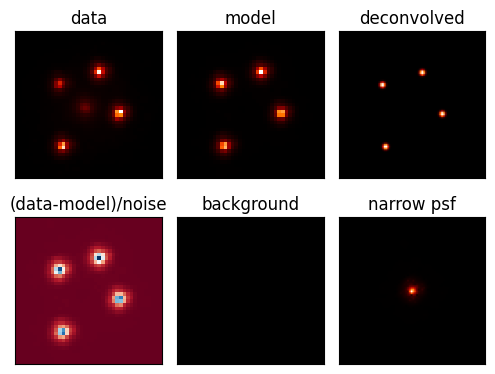

In [231]:
view_deconv_model(model, k_init, data, noisemaps**2, figsize=(5,4))

In [232]:
 # the params needs the initial guess, fixed params and boundaries:
params = ParametersDeconv(k_init, k_fixed, k_up, k_down)
# the loss needs to see our data, noisemaps, model, and the params class:
loss = Loss(data, model, params, noisemaps**2)
# now we can make an optimizer!
optim = Optimizer(loss, params, method='l-bfgs-b')

In [233]:
# optimize (this returns some metrics, but we don't need them here.)
optim.minimize(maxiter=70)
# the best fit is automatically given to the params:
k_optim = params.best_fit_values(as_kwargs=True)

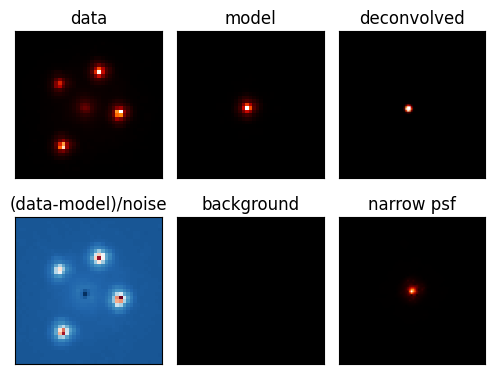

In [234]:
view_deconv_model(model, k_optim, data, noisemaps**2, figsize=(5,4))

In [235]:
 # remove the background fixing:
del k_fixed['kwargs_background']['h']
# calculate the propagation of the noise:
W = propagate_noise(model, noisemaps, k_init, upsampling_factor=2)[0]

In [236]:
# start from our optimized params of before
params = ParametersDeconv(k_optim, k_fixed, k_up, k_down)
# this time we provide the noise scaling to the loss
loss = Loss(data, model, params, noisemaps**2, W=W)
# new optimizer!
optim = Optimizer(loss, params, method='l-bfgs-b')
# let's go directly:
optim.minimize(maxiter=30)
k_optim_with_background = params.best_fit_values(as_kwargs=True).copy()

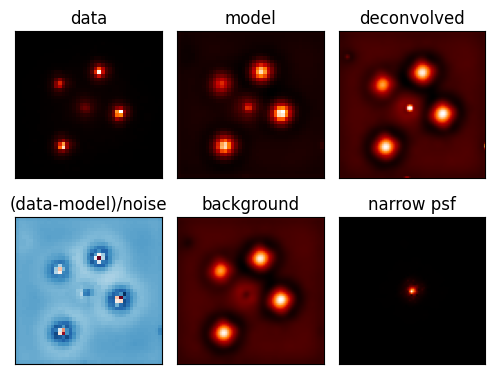

In [237]:
view_deconv_model(model, k_optim_with_background, data, noisemaps**2, figsize=(5,4))